In [1]:
import numpy as np
import pandas as pd
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# 1 . Data Generation with disease induced Deaths

## 1 . Define Parameters and Create initial values

In [100]:
n = 3  # Number of patches (Guinea, Liberia, Sierra Leone)
N = np.array([12e6, 4.5e6, 6e6])  # Population per patch

sigma = 1/6  # Latent period (~4 days)
gamma = 1/10  # Recovery rate (~10 days)
alpha = 0.04  # Disease-induced death rate (40% CFR)

kappa = np.array([2.0, 1.5, 1.8])  # Contact rates
beta = np.array([0.3, 0.4, 0.35]) #[0.06, 0.07, 0.08])  # Transmission probabilities

## Travel and return rate
g = np.array([0.001, 0.001, 0.001])  # Travel rates
m = np.array([[0, 0.5, 0.5], [0.5, 0, 0.5], [0.5, 0.5, 0]])  # Travel fractions
r = np.array([[0, 0.5, 0.5], [0.5, 0, 0.5], [0.5, 0.5, 0]])  # Return rates

# Initial conditions
S0 = np.zeros((n, n))
E0 = np.zeros((n, n))
I0 = np.zeros((n, n))
R0 = np.zeros((n, n))
D0 = np.zeros((n, n))

## loop and create some susceptible population with given rate
for i in range(n):
    S0[i, i] = N[i] * 0.99
    S0[i, (i+1)%n] = N[i] * 0.005
    S0[i, (i+2)%n] = N[i] * 0.005

# Initial infectives in Guinea
I0[0, 0] = 100
S0[0, 0] -= 100

# Initial infectives in Liberia
I0[1,1] = 10
S0[1,1] -= 10

# Initial infectives in Sierra Leone
I0[2,2] = 10
S0[2,2] -= 10

y0 = np.concatenate([S0.flatten(), E0.flatten(), I0.flatten(), R0.flatten(), D0.flatten()])

In [101]:
y0[0:9]

array([11879900.,    60000.,    60000.,    22500.,  4454990.,    22500.,
          30000.,    30000.,  5939990.])

In [102]:
S0.flatten()

array([11879900.,    60000.,    60000.,    22500.,  4454990.,    22500.,
          30000.,    30000.,  5939990.])

## 2 . Create the SEIRD Patch model

In [103]:
# Model equations
def model(y, t, n, N, sigma, gamma, alpha, kappa, beta, g, m, r):
    S = y[:n*n].reshape(n, n)
    E = y[n*n:2*n*n].reshape(n, n)
    I = y[2*n*n:3*n*n].reshape(n, n)
    R = y[3*n*n:4*n*n].reshape(n, n)
    D = y[4*n*n:].reshape(n, n)

    Np = np.sum(S + E + I + R, axis=0)  # Population in each patch (exclude D)
    dSdt = np.zeros((n, n))
    dEdt = np.zeros((n, n))
    dIdt = np.zeros((n, n))
    dRdt = np.zeros((n, n))
    dDdt = np.zeros((n, n))

    for i in range(n):
        ## residents of Patch i who are currently in Patch j
        j = i
        foi_ii = sum(kappa[j] * beta[j] * S[i, j] * I[k, j] / Np[j] for k in range(n))

        ## calculate the change of each compartment
        dSdt[i, i] = sum(r[i, k] * S[i, k] for k in range(n)) - g[i] * S[i, i] - foi_ii
        dEdt[i, i] = sum(r[i, k] * E[i, k] for k in range(n)) - g[i] * E[i, i] + foi_ii - sigma * E[i, i]
        dIdt[i, i] = sum(r[i, k] * I[i, k] for k in range(n)) - g[i] * I[i, i] + sigma * E[i, i] - (gamma + alpha) * I[i, i]
        dRdt[i, i] = sum(r[i, k] * R[i, k] for k in range(n)) - g[i] * R[i, i] + gamma * I[i, i]
        dDdt[i, i] = alpha * I[i, i]

        ## residents of Patch i who are currently in Patch j
        for j in range(n):
            if j != i:
                foi = sum(kappa[j] * beta[j] * S[i, j] * I[k, j] / Np[j] for k in range(n))

                ## calculate the change of each compartment
                dSdt[i, j] = g[i] * m[j, i] * S[i, i] - r[i, j] * S[i, j] - foi
                dEdt[i, j] = g[i] * m[j, i] * E[i, i] - r[i, j] * E[i, j] + foi - sigma * E[i, j]
                dIdt[i, j] = g[i] * m[j, i] * I[i, i] - r[i, j] * I[i, j] + sigma * E[i, j] - (gamma + alpha) * I[i, j]
                dRdt[i, j] = g[i] * m[j, i] * R[i, i] - r[i, j] * R[i, j] + gamma * I[i, j]
                dDdt[i, j] = alpha * I[i, j]

    return np.concatenate([dSdt.flatten(), dEdt.flatten(), dIdt.flatten(), dRdt.flatten(), dDdt.flatten()])

## 3 . Solve the ODE and index the data

In [127]:
# Solve ODE
T = 720
t = np.linspace(0, T, T)
sol = odeint(model, y0, t, args=(n, N, sigma, gamma, alpha, kappa, beta, g, m, r))

# Simulate SEIR for each region
# states = np.zeros((n, T, 5))
# incidence = np.zeros((n, T))

# Extract and aggregate results
S = sol[:, :n*n].reshape(-1, n, n)
E = sol[:, n*n:2*n*n].reshape(-1, n, n)
I = sol[:, 2*n*n:3*n*n].reshape(-1, n, n)
R = sol[:, 3*n*n:4*n*n].reshape(-1, n, n)
D = sol[:, 4*n*n:].reshape(-1, n, n)
sol[:, :n*n].reshape(-1, n, n)
I_total = np.sum(I, axis=1)
R_total = np.sum(R, axis=1)
D_total = np.sum(D, axis=1)

In [128]:
# phi = 10.0  # Negative binomial dispersion parameter
# mu = 0.01
# reporting_rate = 0.8

# observed_cases = np.zeros((n, T), dtype=int)
# for i in range(n):
#     for t in range(T):
#         mean_cases = reporting_rate * incidence[i, t]
#         # Negative binomial: r = phi (dispersion), p = phi/(phi + mean)
#         if phi + mean_cases > 0:
#             p = phi / (phi + mean_cases)
#         else:
#             p = 0.1
#         r = phi
#         p = np.clip(p, 1e-9, 1.0)
#         observed_cases[i, t] = np.random.negative_binomial(r, p)

## 4 . Create dataframe for easy access

In [129]:
# Create dataset
data = {
    'Date': pd.date_range(start='2013-12-28', periods=T, freq='D'),
    'Day': t.astype(int),
    'S_Guinea': S_total[:, 0],
    'E_Guinea': E_total[:, 0],
    'I_Guinea': I_total[:, 0],
    'R_Guinea': R_total[:, 0],
    'D_Guinea': D_total[:, 0],

    'S_Liberia': S_total[:, 1],
    'E_Liberia': E_total[:, 1],
    'I_Liberia': I_total[:, 1],
    'R_Liberia': R_total[:, 1],
    'D_Liberia': D_total[:, 1],

    'S_SierraLeone': S_total[:, 2],
    'E_SierraLeone': E_total[:, 2],
    'I_SierraLeone': I_total[:, 2],
    'R_SierraLeone': R_total[:, 2],
    'D_SierraLeone': D_total[:, 2],

    'Travel_Rate_Guinea': np.full(T, g[0]),
    'Travel_Rate_Liberia': np.full(T, g[1]),
    'Travel_Rate_SierraLeone': np.full(T, g[2]),

    'Contact_Rate_Guinea': np.full(T, kappa[0]),
    'Contact_Rate_Liberia': np.full(T, kappa[1]),
    'Contact_Rate_SierraLeone': np.full(T, kappa[2])
}

df = pd.DataFrame(data)
df.to_csv('synthetic_ebola_dataset_with_death.csv', index=False)

ValueError: All arrays must be of the same length

In [ ]:
df

,Date,Day,S_Guinea,E_Guinea,I_Guinea,R_Guinea,D_Guinea,S_Liberia,E_Liberia,I_Liberia,...,E_SierraLeone,I_SierraLeone,R_SierraLeone,D_SierraLeone,Travel_Rate_Guinea,Travel_Rate_Liberia,Travel_Rate_SierraLeone,Contact_Rate_Guinea,Contact_Rate_Liberia,Contact_Rate_SierraLeone
0,2013-12-28,0,1.193240e+07,0.000000e+00,1.000000e+02,0.000000e+00,0.000000e+00,4.544990e+06,0.000000e+00,1.000000e+01,...,0.000000e+00,1.000000e+01,0.000000e+00,0.000000e+00,0.001,0.001,0.001,2.0,1.5,1.8
1,2013-12-29,1,1.187070e+07,5.191565e+01,9.120903e+01,9.483551e+00,3.794685e+00,4.586079e+06,5.469478e+00,9.160408e+00,...,5.742033e+00,9.183952e+00,9.532329e-01,3.806569e-01,0.001,0.001,0.001,2.0,1.5,1.8
2,2013-12-30,2,1.181260e+07,9.276353e+01,9.081598e+01,1.852886e+01,7.415271e+00,4.624772e+06,1.025683e+01,9.148415e+00,...,1.078537e+01,9.236711e+00,1.872179e+00,7.469701e-01,0.001,0.001,0.001,2.0,1.5,1.8
3,2013-12-31,3,1.175788e+07,1.282426e+02,9.656128e+01,2.785535e+01,1.114858e+01,4.661208e+06,1.483292e+01,9.750998e+00,...,1.564573e+01,9.939426e+00,2.830744e+00,1.128950e+00,0.001,0.001,0.001,2.0,1.5,1.8
4,2014-01-01,4,1.170635e+07,1.621268e+02,1.071998e+02,3.800917e+01,1.521278e+01,4.695520e+06,1.956060e+01,1.084883e+01,...,2.072093e+01,1.117221e+01,3.886936e+00,1.549949e+00,0.001,0.001,0.001,2.0,1.5,1.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1015,2016-10-08,1015,6.978053e+04,2.263625e-14,-6.282493e-13,8.504542e+06,3.402063e+06,3.503819e+04,-1.711802e-14,-5.654130e-13,...,-9.584152e-15,-3.029347e-13,4.266756e+06,1.706614e+06,0.001,0.001,0.001,2.0,1.5,1.8
1016,2016-10-09,1016,6.978053e+04,2.256683e-14,-6.242318e-13,8.504542e+06,3.402063e+06,3.503819e+04,-1.706563e-14,-5.617972e-13,...,-9.554831e-15,-3.009952e-13,4.266756e+06,1.706614e+06,0.001,0.001,0.001,2.0,1.5,1.8
1017,2016-10-10,1017,6.978053e+04,2.249742e-14,-6.202143e-13,8.504542e+06,3.402063e+06,3.503819e+04,-1.701323e-14,-5.581815e-13,...,-9.525511e-15,-2.990557e-13,4.266756e+06,1.706614e+06,0.001,0.001,0.001,2.0,1.5,1.8
1018,2016-10-11,1018,6.978053e+04,2.242800e-14,-6.161967e-13,8.504542e+06,3.402063e+06,3.503819e+04,-1.696084e-14,-5.545657e-13,...,-9.496190e-15,-2.971162e-13,4.266756e+06,1.706614e+06,0.001,0.001,0.001,2.0,1.5,1.8


## 5 . Plot the data infections for each patch

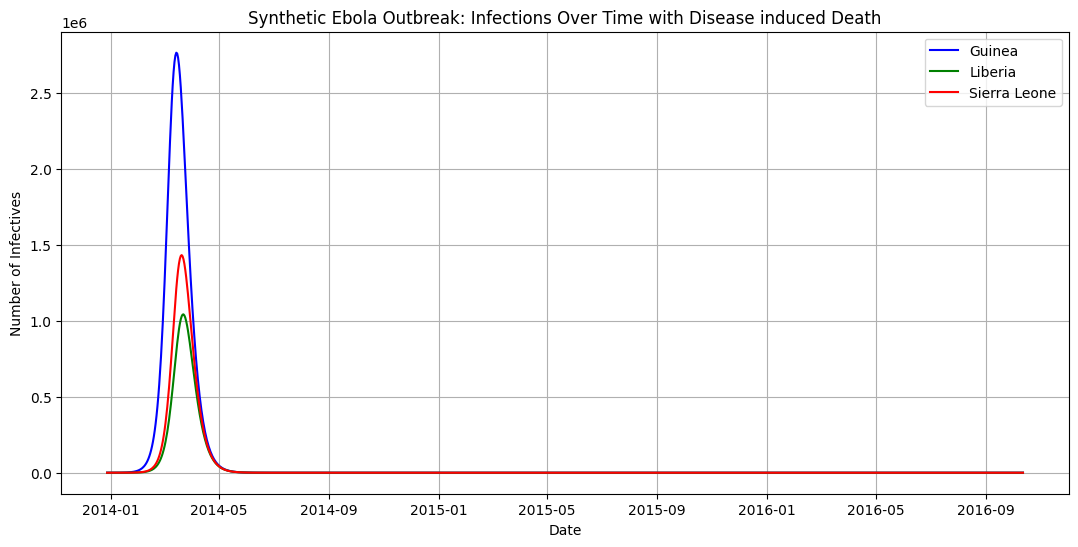

In [ ]:
# Extract data for plotting
days = df['Date']
I_guinea = df['I_Guinea']
I_liberia = df['I_Liberia']
I_sierra_leone = df['I_SierraLeone']

# Create the plot
plt.figure(figsize=(13, 6))
plt.plot(days, I_guinea, label='Guinea', color='blue')
plt.plot(days, I_liberia, label='Liberia', color='green')
plt.plot(days, I_sierra_leone, label='Sierra Leone', color='red')

# Customize the plot
plt.xlabel('Date')
plt.ylabel('Number of Infectives')
plt.title('Synthetic Ebola Outbreak: Infections Over Time with Disease induced Death')
plt.legend()
plt.grid(True)

# Save and show the plot
# plt.savefig('ebola_infections_disease_death_plot.png')
plt.show()

### 6 . Define a function to plot the SEIRD Compartments

In [ ]:
# Plot for each country
countries = ['Guinea', 'Liberia', 'SierraLeone']
def plot_SEIR(df, country_name, Death = False, save=False, yscale = True):
    # Extract data for the current country
    S = df[f'S_{country_name}']
    E = df[f'E_{country_name}']
    I = df[f'I_{country_name}']
    R = df[f'R_{country_name}']

    # Create plot
    plt.figure(figsize=(13, 6))
    plt.plot(df['Date'], S, label='Susceptible', color='blue')
    plt.plot(df['Date'], E, label='Exposed', color='orange')
    plt.plot(df['Date'], I, label='Infective', color='red')
    plt.plot(df['Date'], R, label='Recovered', color='green')
    if Death:
        D = df[f'D_{country_name}']
        plt.plot(df['Date'], D, label='Death', color='black')

    # Customize the plot
    plt.xlabel('Date')
    plt.ylabel('Number of Individuals')
    plt.title(f'SEIRD Dynamics for {country_name}')
    plt.legend()
    plt.grid(True)
    if yscale:
        plt.yscale('symlog')  # Use symlog scale to handle large ranges
    if save:
        plt.savefig(f'seird_{country_name.lower()}.png')
    plt.show()

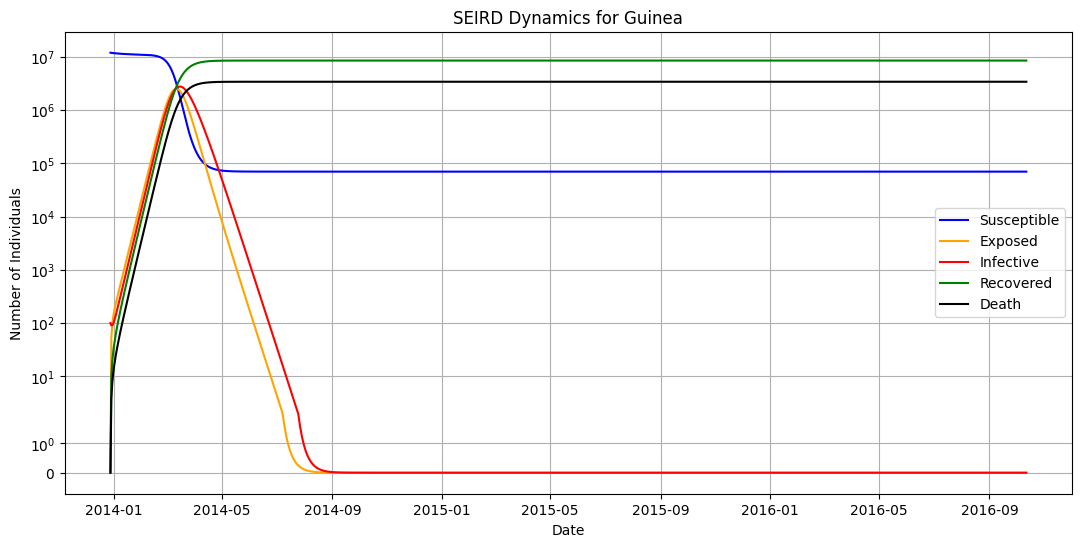

In [ ]:
plot_SEIR(df, 'Guinea', Death=True)

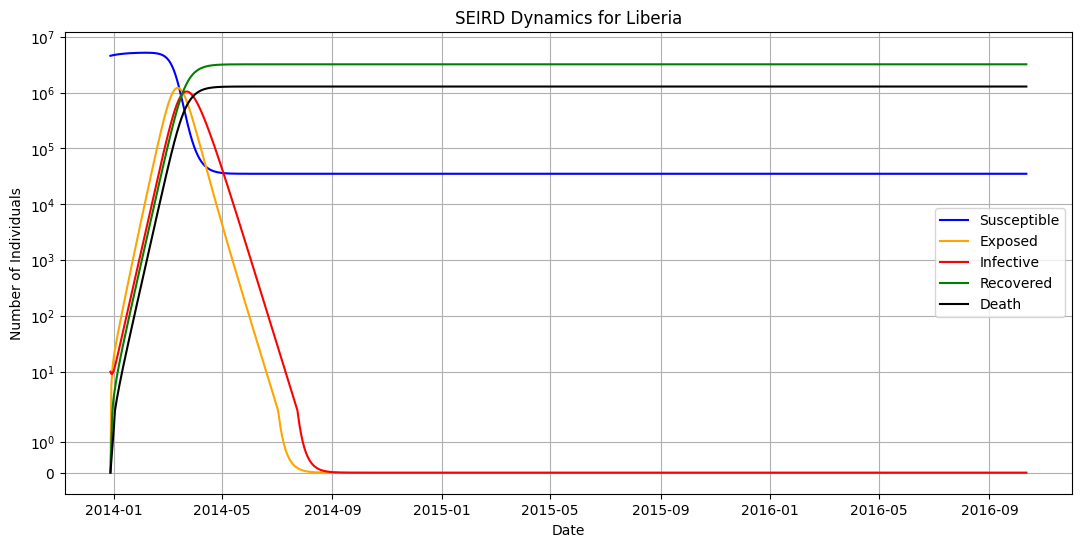

In [ ]:
plot_SEIR(df, 'Liberia', Death=True)

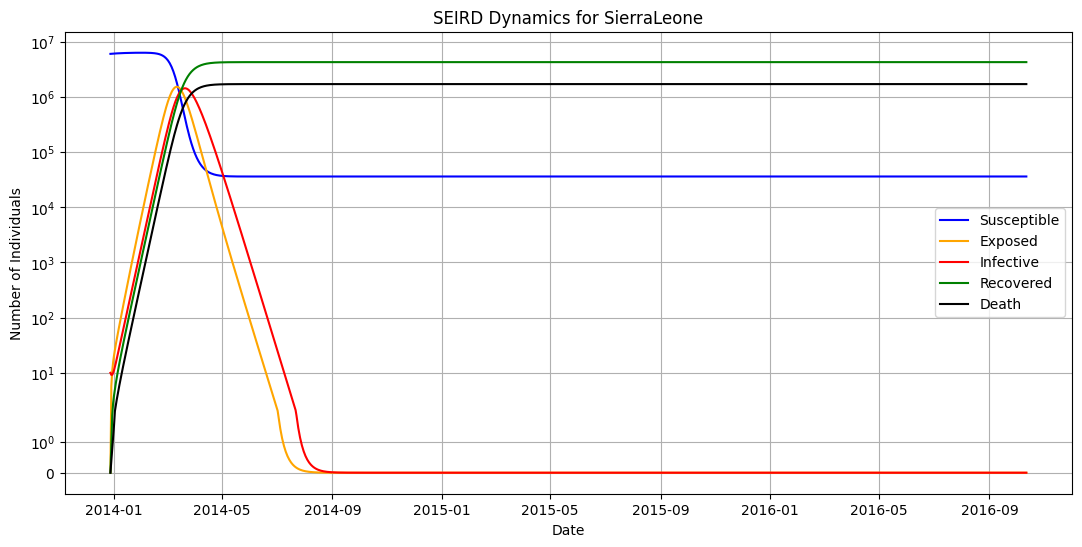

In [ ]:
plot_SEIR(df, 'SierraLeone', Death=True)

# 2 . Without Disease induced Deaths

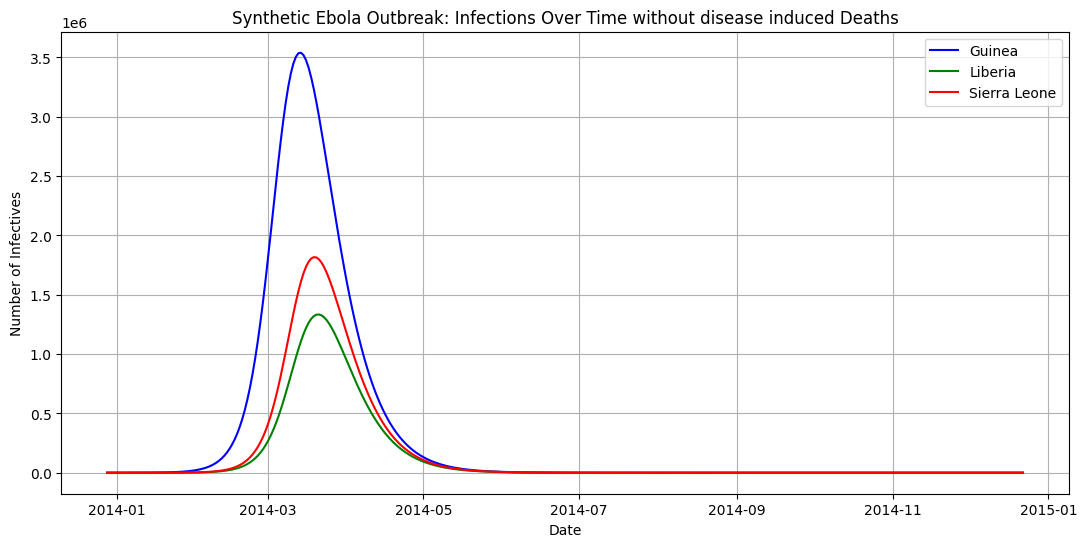

In [ ]:
n = 3
 ## Population per patch (Guinea, Liberia, Sierra Leone)
N = np.array([12e6, 4.5e6, 6e6])

sigma = 1/7  # Latent period (~4 days)
gamma = 1/10  # Recovery rate (~10 days)
kappa = np.array([2.0, 1.5, 1.8])  # Contact rates
beta = np.array([0.3, 0.4, 0.35]) #[0.06, 0.07, 0.08])  # Transmission probabilities

## Travel and return rate
g = np.array([0.001, 0.001, 0.001])  # Travel rates
m = np.array([[0, 0.5, 0.5], [0.5, 0, 0.5], [0.5, 0.5, 0]])  # Travel fractions
r = np.array([[0, 0.5, 0.5], [0.5, 0, 0.5], [0.5, 0.5, 0]])  # Return rates

# Initial conditions: Small outbreak in Guinea
S01 = np.zeros((n, n))
E01 = np.zeros((n, n))
I01 = np.zeros((n, n))
R01 = np.zeros((n, n))

for i in range(n):
    S01[i, i] = N[i] * 0.99  # Most in home patch
    S01[i, (i+1)%n] = N[i] * 0.005
    S01[i, (i+2)%n] = N[i] * 0.005
I01[0, 0] = 100  # Initial infectives in Guinea
S01[0, 0] -= 100

# Initial infectives in Liberia
I01[1,1] = 10
S01[1,1] -= 10

# Initial infectives in Sierra Leone
I01[2,2] = 10
S01[2,2] -= 10

y01 = np.concatenate([S01.flatten(), E01.flatten(), I01.flatten(), R01.flatten()])

# Model equations
def model1(y, t, n, N, epsilon, gamma, kappa, beta, g, m, r):
    S = y[:n*n].reshape(n, n)
    E = y[n*n:2*n*n].reshape(n, n)
    I = y[2*n*n:3*n*n].reshape(n, n)
    R = y[3*n*n:].reshape(n, n)

    Np = np.sum(S + E + I + R, axis=0)  # Population in each patch
    dSdt = np.zeros((n, n))
    dEdt = np.zeros((n, n))
    dIdt = np.zeros((n, n))
    dRdt = np.zeros((n, n))

    for i in range(n):
        ## Calculate ds_dt for the Residents of Patch i currently in Patch i
        j = i

        ## create the force infection
        foi = sum(kappa[j] * beta[j] * S[i, j] * I[k, j] / Np[j] for k in range(n))

        ## calculate the change in the compartments
        dSdt[i, i] = sum(r[i, k] * S[i, k] for k in range(n)) - g[i] * S[i, i] - foi
        dEdt[i, i] = sum(r[i, k] * E[i, k] for k in range(n)) - g[i] * E[i, i] + foi - sigma * E[i, i]
        dIdt[i, i] = sum(r[i, k] * I[i, k] for k in range(n)) - g[i] * I[i, i] + sigma * E[i, i] - gamma * I[i, i]
        dRdt[i, i] = sum(r[i, k] * R[i, k] for k in range(n)) - g[i] * R[i, i] + gamma * I[i, i]

        ## Calculate ds_dt for the Residents of Patch i currently in Patch j
        for j in range(n):
            if j != i:
                ## create force of infection
                foi = sum(kappa[j] * beta[j] * S[i, j] * I[k, j] / Np[j] for k in range(n))

                ## calculate the change in the compartments
                dSdt[i, j] = g[i] * m[j, i] * S[i, i] - r[i, j] * S[i, j] - foi
                dEdt[i, j] = g[i] * m[j, i] * E[i, i] - r[i, j] * E[i, j] + foi - sigma * E[i, j]
                dIdt[i, j] = g[i] * m[j, i] * I[i, i] - r[i, j] * I[i, j] + sigma * E[i, j] - gamma * I[i, j]
                dRdt[i, j] = g[i] * m[j, i] * R[i, i] - r[i, j] * R[i, j] + gamma * I[i, j]

    return np.concatenate([dSdt.flatten(), dEdt.flatten(), dIdt.flatten(), dRdt.flatten()])

T=360
## Solve ODE
t = np.linspace(0, T, T)  # 1020 days (0 to 1020)
sol1 = odeint(model1, y01, t, args=(n, N, sigma, gamma, kappa, beta, g, m, r))

## Extract and aggregate results
S1 = sol1[:, :n*n].reshape(-1, n, n)
E1 = sol1[:, n*n:2*n*n].reshape(-1, n, n)
I1 = sol1[:, 2*n*n:3*n*n].reshape(-1, n, n)
R1 = sol1[:, 3*n*n:].reshape(-1, n, n)

## Total per patch (sum over resident patches i)
S_total1 = np.sum(S1, axis=1)
E_total1 = np.sum(E1, axis=1)
I_total1 = np.sum(I1, axis=1)
R_total1 = np.sum(R1, axis=1)

## Create dataset with time, totals per patch, and parameters
data1= {
    'Date': pd.date_range(start='2013-12-28', periods=T, freq='D'),
    'Day': t.astype(int),
    'S_Guinea': S_total1[:, 0],
    'E_Guinea': E_total1[:, 0],
    'I_Guinea': I_total1[:, 0],
    'R_Guinea': R_total1[:, 0],
    'S_Liberia': S_total1[:, 1],
    'E_Liberia': E_total1[:, 1],
    'I_Liberia': I_total1[:, 1],
    'R_Liberia': R_total1[:, 1],
    'S_SierraLeone': S_total1[:, 2],
    'E_SierraLeone': E_total1[:, 2],
    'I_SierraLeone': I_total1[:, 2],
    'R_SierraLeone': R_total1[:, 2],
    'Travel_Rate_Guinea': np.full(T, g[0]),
    'Travel_Rate_Liberia': np.full(T, g[1]),
    'Travel_Rate_SierraLeone': np.full(T, g[2]),
    'Contact_Rate_Guinea': np.full(T, kappa[0]),
    'Contact_Rate_Liberia': np.full(T, kappa[1]),
    'Contact_Rate_SierraLeone': np.full(T, kappa[2])
}

## Convert to a dataframe
df1 = pd.DataFrame(data1)
# df.to_csv('synthetic_ebola_dataset.csv', index=False)
# print("Synthetic dataset saved as 'synthetic_ebola_dataset.csv'")

## Extract data for plotting
days = df1['Date']
I_guinea1 = df1['I_Guinea']
I_liberia1 = df1['I_Liberia']
I_sierra_leone1 = df1['I_SierraLeone']

## Create the plot
plt.figure(figsize=(13, 6))
plt.plot(days, I_guinea1, label='Guinea', color='blue')
plt.plot(days, I_liberia1, label='Liberia', color='green')
plt.plot(days, I_sierra_leone1, label='Sierra Leone', color='red')

## Customize the plot
plt.xlabel('Date')
plt.ylabel('Number of Infectives')
plt.title('Synthetic Ebola Outbreak: Infections Over Time without disease induced Deaths')
plt.legend()
plt.grid(True)

## Save and show the plot
# plt.savefig('ebola_infections_plot.png')
plt.show()

In [ ]:
df1

,Date,Day,S_Guinea,E_Guinea,I_Guinea,R_Guinea,S_Liberia,E_Liberia,I_Liberia,R_Liberia,S_SierraLeone,E_SierraLeone,I_SierraLeone,R_SierraLeone,Travel_Rate_Guinea,Travel_Rate_Liberia,Travel_Rate_SierraLeone,Contact_Rate_Guinea,Contact_Rate_Liberia,Contact_Rate_SierraLeone
0,2013-12-28,0,1.193240e+07,0.000000e+00,100.000000,0.000000e+00,4.544990e+06,0.000000e+00,10.000000,0.000000e+00,6.022490e+06,0.000000e+00,10.000000,0.000000e+00,0.001,0.001,0.001,2.0,1.5,1.8
1,2013-12-29,1,1.195368e+07,5.397941e+01,94.260155,9.667301e+00,4.530760e+06,5.427948e+00,9.466796,9.708714e-01,6.015372e+06,5.717144e+00,9.487712,9.715932e-01,0.001,0.001,0.001,2.0,1.5,1.8
2,2013-12-30,2,1.196653e+07,9.967620e+01,95.810679,1.913762e+01,4.522147e+06,1.006181e+01,9.650968,1.927174e+00,6.011062e+06,1.063371e+01,9.731608,1.932837e+00,0.001,0.001,0.001,2.0,1.5,1.8
3,2013-12-31,3,1.197428e+07,1.418426e+02,103.161471,2.906271e+01,4.516933e+06,1.435906e+01,10.415804,2.932105e+00,6.008452e+06,1.523680e+01,10.592004,2.950759e+00,0.001,0.001,0.001,2.0,1.5,1.8
4,2014-01-01,4,1.197895e+07,1.839560e+02,115.524560,3.998064e+01,4.513776e+06,1.866406e+01,11.688051,4.039380e+00,6.006869e+06,1.990080e+01,11.996576,4.082682e+00,0.001,0.001,0.001,2.0,1.5,1.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,2014-12-18,355,3.015139e+04,1.141768e-06,0.000036,1.195638e+07,1.134716e+04,8.387951e-07,0.000026,4.497635e+06,1.117840e+04,6.098315e-07,0.000024,5.993313e+06,0.001,0.001,0.001,2.0,1.5,1.8
356,2014-12-19,356,3.015139e+04,1.038339e-06,0.000033,1.195638e+07,1.134716e+04,7.616807e-07,0.000024,4.497635e+06,1.117840e+04,5.532998e-07,0.000022,5.993313e+06,0.001,0.001,0.001,2.0,1.5,1.8
357,2014-12-20,357,3.015139e+04,9.445216e-07,0.000030,1.195638e+07,1.134716e+04,6.915081e-07,0.000022,4.497635e+06,1.117840e+04,5.019162e-07,0.000020,5.993313e+06,0.001,0.001,0.001,2.0,1.5,1.8
358,2014-12-21,358,3.015139e+04,8.593810e-07,0.000027,1.195638e+07,1.134716e+04,6.277319e-07,0.000020,4.497635e+06,1.117840e+04,4.552657e-07,0.000018,5.993313e+06,0.001,0.001,0.001,2.0,1.5,1.8


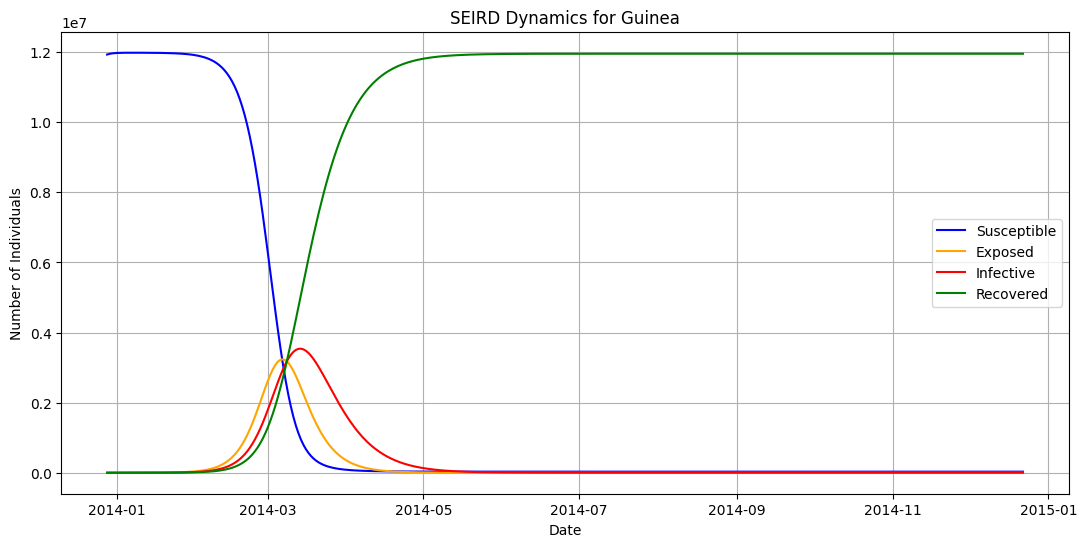

In [ ]:
plot_SEIR(df1, 'Guinea', yscale=False)

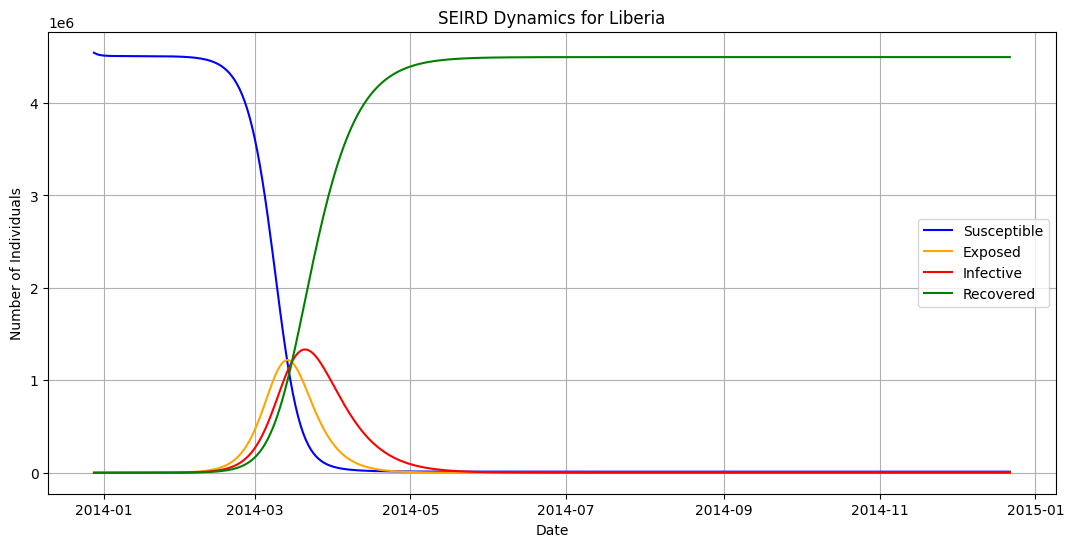

In [ ]:
plot_SEIR(df1, 'Liberia', yscale=False)

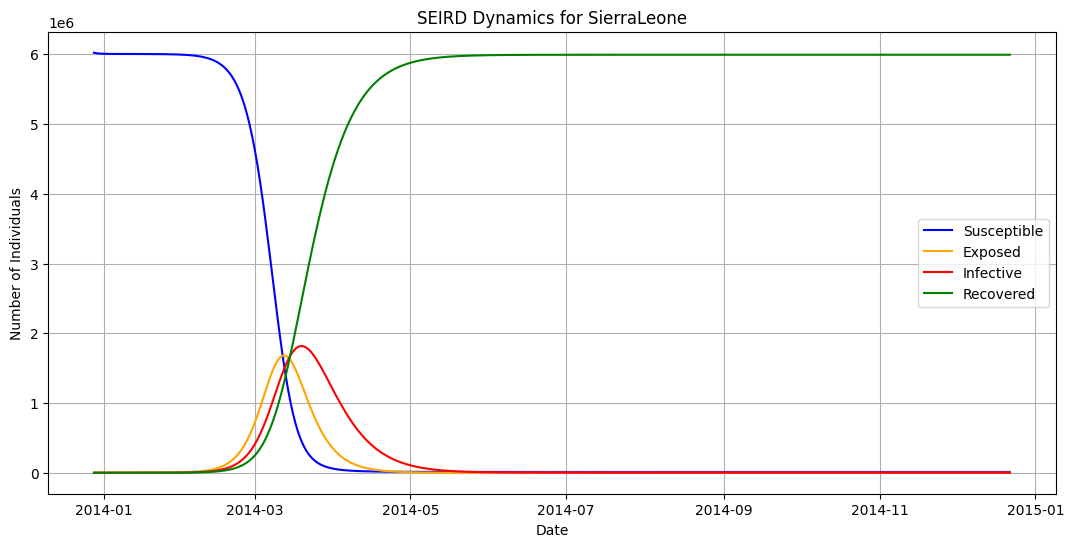

In [ ]:
plot_SEIR(df1, 'SierraLeone', yscale=False)

In [ ]:
import cmdstanpy
cmdstanpy.install_cmdstan()
from cmdstanpy import CmdStanModel

CmdStan install directory: /home/samuela/.cmdstan
CmdStan version 2.36.0 already installed
Test model compilation


In [ ]:
# Load the synthetic dataset
df = pd.read_csv('synthetic_ebola_dataset_with_death.csv')

# Prepare data for Stan
P = 3
T = len(df)
t0 = -1
ts = df['Day'].values
I_obs = df[['I_Guinea', 'I_Liberia', 'I_SierraLeone']].values.astype(int)
D_obs = df[['D_Guinea', 'D_Liberia', 'D_SierraLeone']].values.astype(int)
N = np.array([12e6, 4.5e6, 6e6])
E0 = np.array([0, 0, 0])
I0 = np.array([100, 0, 0])

stan_data = {
    'P': P,
    'T': T,
    't0': t0,
    'ts': ts,
    'I_obs': I_obs,
    'D_obs': D_obs,
    'N': N,
    'E0': E0,
    'I0': I0
}

In [ ]:
# Compile and run the Stan model
model = CmdStanModel(stan_file='coupling.stan')
fit = model.sample(data=stan_data,
                   chains=4,
                   parallel_chains=4,
                   iter_warmup=10,
                   iter_sampling=10)

ValueError: no such file /var/autofs/misc/home/samuela/Documents/thesis/myvenv/thesis/coupling.stan

In [ ]:
# Summarize results
print(fit.summary())
fit.save_csvfiles('stan_output_seird')
print("Stan output saved in 'stan_output_seird' directory")